# **Cell 1 – Structure Scanner + Paths DBPython**

In [2]:
import os
import json
from pathlib import Path
from datetime import datetime
import pandas as pd
from IPython.display import display

# ============================================================
# CONFIG
# ============================================================
ROOT = Path("/kaggle/input")
GROUP_NAME = "rfmid-multilabel"

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.gif', '.webp'}
META_EXTS  = {'.csv', '.tsv', '.xlsx', '.xls', '.json', '.txt', '.xml'}

structure = {}
meta_files = []

def is_image(p: Path) -> bool:
    return p.suffix.lower() in IMAGE_EXTS

def walk(path: Path, current_dict: dict):
    print(f"Checking → {path}")
    
    try:
        entries = sorted(path.iterdir())
    except PermissionError:
        print(f"  ⚠️  Permission denied: {path}")
        return

    has_image = any(is_image(e) for e in entries if e.is_file())
    
    if has_image:
        current_dict["__contains_images__"] = True
        current_dict["__subdirs__"] = [e.name for e in entries if e.is_dir()]
        print(f"  → Contains images. Stopping deeper traversal.")
        return

    for entry in entries:
        if entry.is_dir():
            current_dict[entry.name] = {}
            walk(entry, current_dict[entry.name])
        elif entry.suffix.lower() in META_EXTS:
            meta_files.append(str(entry))
            current_dict.setdefault("__meta_files__", []).append(entry.name)
            print(f"  → Found metadata: {entry.name}")

# ============================================================
# RUN SCAN
# ============================================================
print(f"Scanning structure for group: {GROUP_NAME}\n")
walk(ROOT, structure)

# Save structure
structure_path = f"/kaggle/working/{GROUP_NAME}_structure.json"
with open(structure_path, "w") as f:
    json.dump(structure, f, indent=2)
print(f"\n✅ Structure JSON saved → {structure_path}")

# ============================================================
# PATHS DB (will be completed after scan)
# ============================================================
paths_db = {
    "group": GROUP_NAME,
    "created": datetime.now().isoformat(),
    "datasets": {
        "RFMiD": {
            "kaggle_slug": "sohailaelsayed/retinal-fundus-multi-disease-rfmid",
            "root": "",               # will fill after scan
            "images_folder": "",
            "csv": "",
            "type": "csv_based / multi-label",
            "classes": "46 conditions (multi-label)",
            "notes": "Retinal Fundus Multi-disease Image Dataset"
        }
    }
}

paths_path = f"/kaggle/working/{GROUP_NAME}_paths_db.json"
with open(paths_path, "w") as f:
    json.dump(paths_db, f, indent=2)
print(f"✅ Paths DB skeleton saved → {paths_path}")

# ============================================================
# SHOW METADATA
# ============================================================
print("\n===== METADATA / CSV FILES FOUND =====")
if meta_files:
    df_meta = pd.DataFrame({
        "Metadata File": meta_files,
        "Parent Folder": [str(Path(p).parent) for p in meta_files]
    })
    display(df_meta)
else:
    print("No CSV / metadata files found.")

print("\nDone. Paste the scan output (especially metadata table) so I can complete the paths_db.")

Scanning structure for group: rfmid-multilabel

Checking → /kaggle/input
Checking → /kaggle/input/datasets
Checking → /kaggle/input/datasets/sohailaelsayed
Checking → /kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid
Checking → /kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images
Checking → /kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images
Checking → /kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/a. Training Set
  → Contains images. Stopping deeper traversal.
Checking → /kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/b. Validation Set
  → Contains images. Stopping deeper traversal.
Checking → /kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/c. Testing Set
  → Contains images. Sto

,Metadata File,Parent Folder
0,/kaggle/input/datasets/sohailaelsayed/retinal-...,/kaggle/input/datasets/sohailaelsayed/retinal-...
1,/kaggle/input/datasets/sohailaelsayed/retinal-...,/kaggle/input/datasets/sohailaelsayed/retinal-...
2,/kaggle/input/datasets/sohailaelsayed/retinal-...,/kaggle/input/datasets/sohailaelsayed/retinal-...



Done. Paste the scan output (especially metadata table) so I can complete the paths_db.


# **Final Paths DB**

In [3]:
import json
from datetime import datetime

paths_db = {
    "group": "rfmid-multilabel",
    "created": datetime.now().isoformat(),
    "datasets": {
        "RFMiD": {
            "kaggle_slug": "sohailaelsayed/retinal-fundus-multi-disease-rfmid",
            "root": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid",
            "images_train": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/a. Training Set",
            "images_val": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/b. Validation Set",
            "images_test": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/c. Testing Set",
            "csv_train": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtruths/2. Groundtruths/a. RFMiD_Training_Labels.csv",
            "csv_val": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtruths/2. Groundtruths/b. RFMiD_Validation_Labels.csv",
            "csv_test": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtruths/2. Groundtruths/c. RFMiD_Testing_Labels.csv",
            "type": "multi-label",
            "classes": "46 conditions (multi-label)",
            "notes": "Official RFMiD – Training / Validation / Testing splits"
        }
    }
}

with open("/kaggle/working/rfmid-multilabel_paths_db.json", "w") as f:
    json.dump(paths_db, f, indent=2)

print("✅ paths_db saved")
print(json.dumps(paths_db, indent=2))

✅ paths_db saved
{
  "group": "rfmid-multilabel",
  "created": "2026-09-23T12:06:47.565076",
  "datasets": {
    "RFMiD": {
      "kaggle_slug": "sohailaelsayed/retinal-fundus-multi-disease-rfmid",
      "root": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid",
      "images_train": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/a. Training Set",
      "images_val": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/b. Validation Set",
      "images_test": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/c. Testing Set",
      "csv_train": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtruths/2. Groundtruths/a. RFMiD_Training_Labels.csv",
      "csv_val": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtr

In [6]:
import os
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")

def analyze_dataset(dataset_name: str, root_path: str, class_folders: list = None, 
                    csv_path: str = None, label_col: str = None, image_col: str = None,
                    max_samples_per_class: int = 3):
    """
    Universal analyzer for fundus datasets.
    """
    
    print("="*80)
    print(f"DATASET: {dataset_name}")
    print("="*80)
    
    root = Path(root_path)
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    
    data = []
    
    if csv_path is not None:
        df = pd.read_csv(csv_path)
        print(f"CSV loaded: {csv_path}  |  shape = {df.shape}")
        print("Columns:", df.columns.tolist())
        
        if label_col is None or image_col is None:
            print("⚠️  Please provide label_col and image_col")
            return
        
        for _, row in df.iterrows():
            img_name = str(row[image_col])
            label = str(row[label_col])
            possible = list(root.rglob(img_name))
            if not possible:
                possible = list(root.rglob(f"*{Path(img_name).stem}*"))
            if possible:
                data.append((label, possible[0]))
    else:
        if class_folders is None:
            class_folders = []
            for p in root.iterdir():
                if p.is_dir():
                    has_img = any(f.suffix.lower() in image_exts for f in p.rglob("*") if f.is_file())
                    if has_img:
                        class_folders.append(p.name)
        
        print(f"Class folders found: {class_folders}")
        
        for cls in class_folders:
            cls_path = root / cls
            if not cls_path.exists():
                matches = list(root.rglob(cls))
                if matches:
                    cls_path = matches[0]
                else:
                    continue
            
            for img_path in cls_path.rglob("*"):
                if img_path.suffix.lower() in image_exts:
                    data.append((cls, img_path))
    
    if len(data) == 0:
        print("❌ No images found. Check the path.")
        return
    
    # Summary table
    class_counts = Counter([d[0] for d in data])
    total_images = sum(class_counts.values())
    
    res_per_class = defaultdict(set)
    size_per_class = defaultdict(list)
    
    print("\nCollecting resolution & size info...")
    for cls, path in data:
        try:
            img = cv2.imread(str(path))
            if img is None:
                continue
            h, w = img.shape[:2]
            res_per_class[cls].add(f"{w}x{h}")
            size_mb = path.stat().st_size / (1024 * 1024)
            size_per_class[cls].append(size_mb)
        except:
            pass
    
    rows = []
    for cls in sorted(class_counts.keys()):
        count = class_counts[cls]
        pct = count / total_images * 100
        resolutions = ", ".join(sorted(res_per_class[cls])) if res_per_class[cls] else "N/A"
        avg_size = np.mean(size_per_class[cls]) if size_per_class[cls] else 0
        rows.append({
            "Class": cls,
            "Image Count": count,
            "Percentage": f"{pct:.1f}%",
            "Resolution(s)": resolutions,
            "Avg Size (MB)": f"{avg_size:.3f}"
        })
    
    all_sizes = [s for sizes in size_per_class.values() for s in sizes]
    rows.append({
        "Class": "TOTAL",
        "Image Count": total_images,
        "Percentage": "100%",
        "Resolution(s)": "-",
        "Avg Size (MB)": f"{np.mean(all_sizes):.3f}" if all_sizes else "0"
    })
    
    df_summary = pd.DataFrame(rows)
    print("\n----- SUMMARY TABLE -----")
    display(df_summary)
    
    # Sample images
    print("\n----- SAMPLE IMAGES PER CLASS -----")
    classes = sorted(class_counts.keys())
    samples = defaultdict(list)
    for cls, path in data:
        if len(samples[cls]) < max_samples_per_class:
            samples[cls].append(path)
    
    cols = min(max_samples_per_class, 3)
    rows_plot = len(classes)
    
    fig, axes = plt.subplots(rows_plot, cols, figsize=(4*cols, 3.5*rows_plot))
    if rows_plot == 1:
        axes = np.array([axes])
    if cols == 1:
        axes = axes.reshape(-1, 1)
    
    for i, cls in enumerate(classes):
        for j in range(cols):
            ax = axes[i, j]
            if j < len(samples[cls]):
                img = cv2.imread(str(samples[cls][j]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                ax.set_title(f"{cls}", fontsize=10)
            ax.axis("off")
    
    plt.suptitle(f"{dataset_name} – Sample Images", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    
    # Stats
    print("\n----- IMAGE STATISTICAL ANALYSIS -----")
    all_widths, all_heights, all_sizes_mb = [], [], []
    channels = []
    
    for cls, path in data[:min(500, len(data))]:
        try:
            img = cv2.imread(str(path))
            if img is None:
                continue
            h, w = img.shape[:2]
            all_widths.append(w)
            all_heights.append(h)
            all_sizes_mb.append(path.stat().st_size / (1024*1024))
            channels.append(img.shape[2] if len(img.shape) == 3 else 1)
        except:
            pass
    
    stats = {
        "Total Images Analyzed": len(all_widths),
        "Unique Resolutions": len(set(zip(all_widths, all_heights))),
        "Width  – min / mean / max": f"{min(all_widths)} / {np.mean(all_widths):.0f} / {max(all_widths)}",
        "Height – min / mean / max": f"{min(all_heights)} / {np.mean(all_heights):.0f} / {max(all_heights)}",
        "File Size (MB) – min / mean / max": f"{min(all_sizes_mb):.3f} / {np.mean(all_sizes_mb):.3f} / {max(all_sizes_mb):.3f}",
        "Channels (most common)": Counter(channels).most_common(1)[0][0] if channels else "N/A"
    }
    
    for k, v in stats.items():
        print(f"{k:35s} : {v}")
    
    print("\n" + "="*80 + "\n")

# **Analysis Cell**

DATASET: RFMiD (Training)
CSV loaded: /kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtruths/2. Groundtruths/a. RFMiD_Training_Labels.csv  |  shape = (1920, 47)
Columns: ['ID', 'Disease_Risk', 'DR', 'ARMD', 'MH', 'DN', 'MYA', 'BRVO', 'TSLN', 'ERM', 'LS', 'MS', 'CSR', 'ODC', 'CRVO', 'TV', 'AH', 'ODP', 'ODE', 'ST', 'AION', 'PT', 'RT', 'RS', 'CRS', 'EDN', 'RPEC', 'MHL', 'RP', 'CWS', 'CB', 'ODPM', 'PRH', 'MNF', 'HR', 'CRAO', 'TD', 'CME', 'PTCR', 'CF', 'VH', 'MCA', 'VS', 'BRAO', 'PLQ', 'HPED', 'CL']


----- SUMMARY TABLE -----


,Class,Image Count,Percentage,Resolution(s),Avg Size (MB)
0,0,401,20.9%,"2048x1536, 2144x1424, 4288x2848",3.065
1,1,1519,79.1%,"2048x1536, 2144x1424, 4288x2848",2.720
2,TOTAL,1920,100%,-,2.792



----- SAMPLE IMAGES PER CLASS -----


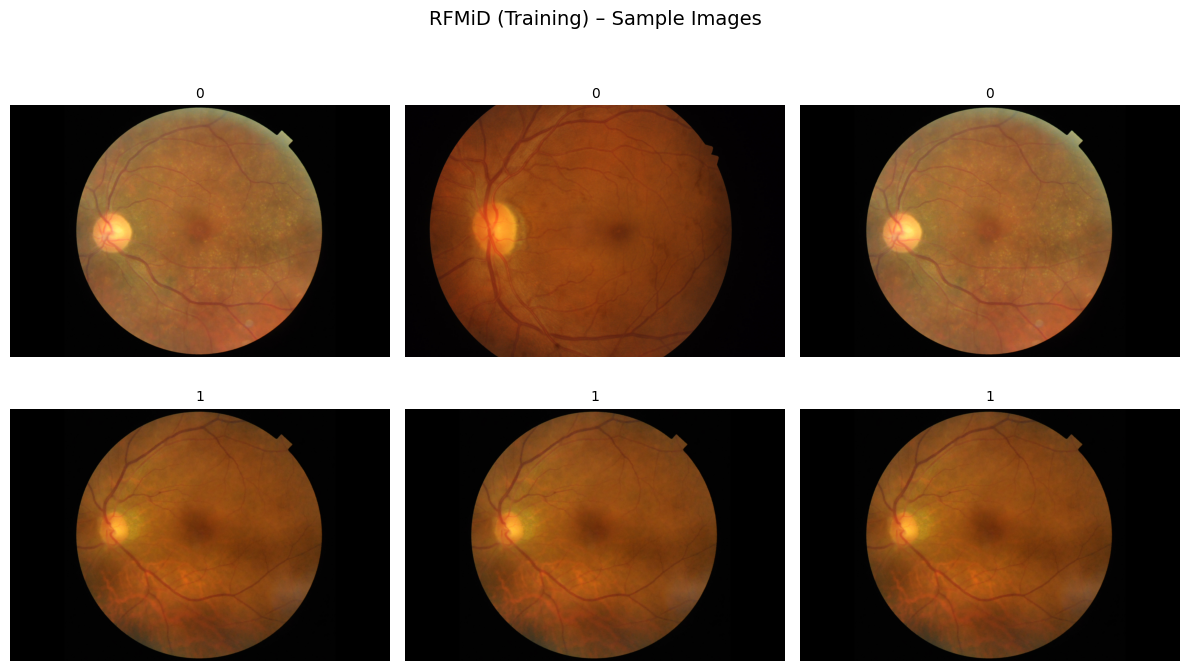


----- IMAGE STATISTICAL ANALYSIS -----
Total Images Analyzed               : 500
Unique Resolutions                  : 3
Width  – min / mean / max           : 2048 / 2333 / 4288
Height – min / mean / max           : 1424 / 1557 / 2848
File Size (MB) – min / mean / max   : 1.357 / 2.094 / 7.382
Channels (most common)              : 3




In [7]:
# RFMiD - Training Set
analyze_dataset(
    dataset_name = "RFMiD (Training)",
    root_path    = "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/a. Training Set",
    csv_path     = "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtruths/2. Groundtruths/a. RFMiD_Training_Labels.csv",
    label_col    = "Disease_Risk",   # will confirm after loading
    image_col    = "ID"              # will confirm after loading
)

In [8]:
import json
import pandas as pd
from pathlib import Path
from datetime import datetime
from IPython.display import display

# ============================================================
# 1. PATHS DATABASE
# ============================================================
paths_db = {
    "group": "rfmid-multilabel",
    "created": datetime.now().isoformat(),
    "datasets": {
        "RFMiD": {
            "kaggle_slug": "sohailaelsayed/retinal-fundus-multi-disease-rfmid",
            "root": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid",
            "images_train": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/a. Training Set",
            "images_val": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/b. Validation Set",
            "images_test": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/1. Original Images/1. Original Images/c. Testing Set",
            "csv_train": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtruths/2. Groundtruths/a. RFMiD_Training_Labels.csv",
            "csv_val": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtruths/2. Groundtruths/b. RFMiD_Validation_Labels.csv",
            "csv_test": "/kaggle/input/datasets/sohailaelsayed/retinal-fundus-multi-disease-rfmid/2. Groundtruths/2. Groundtruths/c. RFMiD_Testing_Labels.csv",
            "type": "multi-label",
            "classes": "46 conditions (multi-label)",
            "notes": "Official RFMiD dataset with Train / Val / Test splits"
        }
    }
}

# ============================================================
# 2. SUMMARY LOGS DB
# (Fill after you run analyze_dataset)
# ============================================================
summary_db = {
    "group": "rfmid-multilabel",
    "created": datetime.now().isoformat(),
    "results": {
        # Example – replace with real numbers later
        # "RFMiD (Training)": {
        #     "total_images": 1920,
        #     "classes": {"Disease_Risk": ...},
        #     "resolution": "...",
        #     "avg_size_mb": 0.0
        # }
    }
}

# ============================================================
# 3. MASTER TABLE + SIZE + TOTALS
# ============================================================
def get_folder_size_mb(folder_path: str) -> float:
    total = 0
    path = Path(folder_path)
    if not path.exists():
        return 0.0
    for f in path.rglob("*"):
        if f.is_file():
            total += f.stat().st_size
    return total / (1024 * 1024)

master_rows = []

for name, info in paths_db["datasets"].items():
    # For RFMiD we calculate size of the training images folder
    images_folder = info.get("images_train") or info.get("root")
    size_mb = get_folder_size_mb(images_folder)
    result = summary_db["results"].get(name, {})
    
    master_rows.append({
        "Dataset": name,
        "Kaggle_Slug": info["kaggle_slug"],
        "Type": info["type"],
        "Num_Classes": info["classes"],
        "Total_Images": result.get("total_images", 0),
        "Resolution": result.get("resolution", ""),
        "Avg_Size_MB": result.get("avg_size_mb", 0),
        "Total_Size_MB": round(size_mb, 1),
        "Total_Size_GB": round(size_mb / 1024, 2),
        "Root_Path": info["root"],
        "Images_Train": info.get("images_train", ""),
        "CSV_Train": info.get("csv_train", ""),
        "Notes": info.get("notes", "")
    })

df_master = pd.DataFrame(master_rows)

# Grand Totals
total_images = df_master["Total_Images"].sum()
total_size_mb = df_master["Total_Size_MB"].sum()
total_size_gb = total_size_mb / 1024

print("=" * 80)
print("MASTER SUMMARY TABLE – rfmid-multilabel")
print("=" * 80)
display(df_master)

print("\n" + "=" * 80)
print("GRAND TOTALS")
print("=" * 80)
print(f"Total Datasets     : {len(df_master)}")
print(f"Total Images       : {total_images:,}")
print(f"Total Size         : {total_size_mb:,.1f} MB  ({total_size_gb:.2f} GB)")
print("=" * 80)

# Save files
df_master.to_csv("/kaggle/working/rfmid-multilabel_master_table.csv", index=False)

with open("/kaggle/working/rfmid-multilabel_paths_db.json", "w") as f:
    json.dump(paths_db, f, indent=2)

with open("/kaggle/working/rfmid-multilabel_summary_db.json", "w") as f:
    json.dump(summary_db, f, indent=2)

print("\n✅ Files saved:")
print(" - rfmid-multilabel_paths_db.json")
print(" - rfmid-multilabel_summary_db.json")
print(" - rfmid-multilabel_master_table.csv")

MASTER SUMMARY TABLE – rfmid-multilabel


,Dataset,Kaggle_Slug,Type,Num_Classes,Total_Images,Resolution,Avg_Size_MB,Total_Size_MB,Total_Size_GB,Root_Path,Images_Train,CSV_Train,Notes
0,RFMiD,sohailaelsayed/retinal-fundus-multi-disease-rfmid,multi-label,46 conditions (multi-label),0,,0,4464.0,4.36,/kaggle/input/datasets/sohailaelsayed/retinal-...,/kaggle/input/datasets/sohailaelsayed/retinal-...,/kaggle/input/datasets/sohailaelsayed/retinal-...,Official RFMiD dataset with Train / Val / Test...



GRAND TOTALS
Total Datasets     : 1
Total Images       : 0
Total Size         : 4,464.0 MB  (4.36 GB)

✅ Files saved:
 - rfmid-multilabel_paths_db.json
 - rfmid-multilabel_summary_db.json
 - rfmid-multilabel_master_table.csv
